# Setup & Imports

In [1]:
# Optional (uncomment if needed)
# !pip install -U yfinance transformers torch pandas matplotlib

import numpy as np, pandas as pd, matplotlib.pyplot as plt, pytz
import yfinance as yf
from pandas.tseries.offsets import BDay
plt.rcParams["figure.figsize"] = (10,4)
NY_TZ = pytz.timezone("America/New_York")


# Yahoo News Fetch (works for flat/nested schemas)

In [2]:
def fetch_yahoo_news(tickers, verbose=True):
    import numpy as np, pandas as pd, yfinance as yf

    def _norm_ts(ts):
        if ts is None or (isinstance(ts, float) and np.isnan(ts)): return pd.NaT
        try:
            if isinstance(ts, (int, float)):
                unit = "ms" if ts > 1e12 else "s"
                return pd.to_datetime(ts, unit=unit, utc=True, errors="coerce")
            return pd.to_datetime(ts, utc=True, errors="coerce")
        except Exception: return pd.NaT

    def _as_list(x):
        return [str(t).upper().replace(".", "-") for t in x] if isinstance(x,(list,tuple,set)) else []

    def _parse(it, src):
        c = it.get("content") or {}
        return {
            "uuid": it.get("uuid") or it.get("id"),
            "title": it.get("title") or c.get("title"),
            "link": it.get("link") or (c.get("canonicalUrl") or {}).get("url") or c.get("url"),
            "publisher": it.get("publisher") or (c.get("provider") or {}).get("displayName") or (c.get("publisher") or {}).get("name"),
            "providerPublishTime": it.get("providerPublishTime") or c.get("pubDate") or c.get("publishTime") or c.get("publishedAt") or c.get("published"),
            "relatedTickers": _as_list(it.get("relatedTickers") or c.get("symbols") or c.get("tickerSymbols") or []),
            "source_ticker": src
        }

    rows = []
    for t in map(str.upper, tickers):
        items = yf.Ticker(t).news or []
        if verbose: print(f"{t}: {len(items)} items")
        rows.extend(_parse(dict(it), t) for it in items)

    df = pd.DataFrame(rows)
    if df.empty: return df
    if df["uuid"].notna().any(): df = df.drop_duplicates(subset=["uuid"])
    elif df["link"].notna().any(): df = df.drop_duplicates(subset=["link"])
    df["published_utc"] = df["providerPublishTime"].apply(_norm_ts)
    empty = df["relatedTickers"].map(len).eq(0)
    df.loc[empty, "relatedTickers"] = df.loc[empty, "source_ticker"].apply(lambda x: [x])
    return df.reset_index(drop=True)


# Pick Tickers & Fetch News

In [3]:
tickers = ["AAPL","MSFT","NVDA","TSLA"]
news_raw = fetch_yahoo_news(tickers, verbose=True)
news_raw[["published_utc","publisher","title","relatedTickers"]].head(8)


AAPL: 10 items
MSFT: 10 items
NVDA: 10 items
TSLA: 10 items


,published_utc,publisher,title,relatedTickers
0,2025-12-18 12:00:39+00:00,Yahoo Finance Video,"Amazon, Apple, Google, etc.: Why the Mag 7 nee...",[AAPL]
1,2025-12-18 23:56:19+00:00,TechCrunch,Apple becomes a debt collector with its new de...,[AAPL]
2,2025-12-18 21:34:59+00:00,The Wall Street Journal,Heard on the Street Recap: Memory Boost,[AAPL]
3,2025-12-18 20:34:54+00:00,24/7 Wall St.,Why 2026 May Be Apple’s Year,[AAPL]
4,2025-12-18 19:56:59+00:00,Investor's Business Daily,These Techs Had The Biggest Stock Buybacks In ...,[AAPL]
5,2025-12-18 19:04:35+00:00,GuruFocus.com,Apple Plans More Ads in App Store,[AAPL]
6,2025-12-18 18:21:31+00:00,GuruFocus.com,Apple Loosens iOS Grip in Japan,[AAPL]
7,2025-12-18 17:08:00+00:00,Barrons.com,America’s 3 Most Important Companies Are About...,[AAPL]


# Map Articles to a “News Day”

In [4]:
news = news_raw.explode("relatedTickers").rename(columns={"relatedTickers":"ticker"})
news["ticker"] = news["ticker"].str.upper()
news = news[news["ticker"].isin(tickers)].copy()

news["published_ny"] = news["published_utc"].dt.tz_convert(NY_TZ)
cutoff = news["published_ny"].dt.normalize() + pd.Timedelta(hours=16)
same_day = news["published_ny"] <= cutoff
news["news_day"] = news["published_ny"].dt.normalize()
news.loc[~same_day, "news_day"] += BDay(1)
news["news_day"] = pd.to_datetime(news["news_day"]).dt.tz_localize(None)

news[["published_utc","news_day","ticker","title"]].head(8)


,published_utc,news_day,ticker,title
0,2025-12-18 12:00:39+00:00,2025-12-18,AAPL,"Amazon, Apple, Google, etc.: Why the Mag 7 nee..."
1,2025-12-18 23:56:19+00:00,2025-12-19,AAPL,Apple becomes a debt collector with its new de...
2,2025-12-18 21:34:59+00:00,2025-12-19,AAPL,Heard on the Street Recap: Memory Boost
3,2025-12-18 20:34:54+00:00,2025-12-18,AAPL,Why 2026 May Be Apple’s Year
4,2025-12-18 19:56:59+00:00,2025-12-18,AAPL,These Techs Had The Biggest Stock Buybacks In ...
5,2025-12-18 19:04:35+00:00,2025-12-18,AAPL,Apple Plans More Ads in App Store
6,2025-12-18 18:21:31+00:00,2025-12-18,AAPL,Apple Loosens iOS Grip in Japan
7,2025-12-18 17:08:00+00:00,2025-12-18,AAPL,America’s 3 Most Important Companies Are About...


# FinBERT (Finance-Tuned Sentiment)

In [5]:
# !pip install -U transformers torch   # if needed
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch, numpy as np

MODEL = "yiyanghkust/finbert-tone"
tok = AutoTokenizer.from_pretrained(MODEL)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL)

def finbert_score(text: str) -> float:
    if not isinstance(text, str) or not text.strip(): return 0.0
    inputs = tok(text[:512], return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = mdl(**inputs).logits.numpy().squeeze()
    p = np.exp(logits) / np.exp(logits).sum()
    return float(p[2] - p[0])  # P(pos) - P(neg) in [-1, +1]


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

c:\Users\mar_c\OneDrive\Documentos\Programacion\IA\entorno\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mar_c\.cache\huggingface\hub\models--yiyanghkust--finbert-tone. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

# Score Headlines & Aggregate

In [6]:
news["score"] = news["title"].fillna("").apply(finbert_score)

daily = (news.groupby(["news_day","ticker"])
              .agg(sent_mean=("score","mean"),
                   art_count=("score","count"))
              .reset_index())
daily.head(10)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


,news_day,ticker,sent_mean,art_count
0,2025-11-05,NVDA,-0.471007,1
1,2025-12-18,AAPL,-0.735062,8
2,2025-12-18,MSFT,-0.396858,5
3,2025-12-18,TSLA,-0.991997,1
4,2025-12-19,AAPL,-0.499732,2
5,2025-12-19,MSFT,-0.352005,5
6,2025-12-19,NVDA,-0.363032,8
7,2025-12-19,TSLA,-0.257076,8


# Visualise: Sentiment & Article Count (recent 90 days)

C:\Users\mar_c\AppData\Local\Temp\ipykernel_39660\3274077267.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  d = daily[daily["ticker"]==tkr].set_index("news_day").sort_index().last("90D")


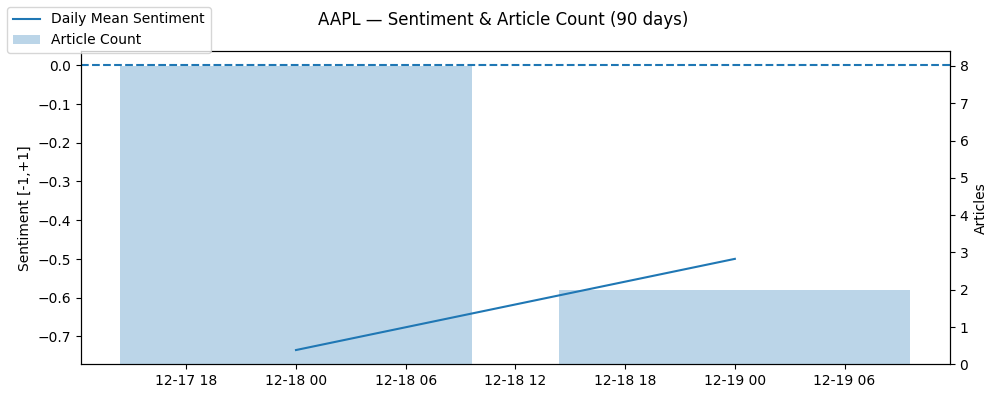

In [7]:
tkr = "AAPL"  # pick one
d = daily[daily["ticker"]==tkr].set_index("news_day").sort_index().last("90D")

fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(d.index, d["sent_mean"], label="Daily Mean Sentiment")
ax1.axhline(0, linestyle="--")
ax1.set_ylabel("Sentiment [-1,+1]")

ax2 = ax1.twinx()
ax2.bar(d.index, d["art_count"], alpha=0.3, label="Article Count")
ax2.set_ylabel("Articles")

fig.suptitle(f"{tkr} — Sentiment & Article Count (90 days)")
fig.legend(loc="upper left"); plt.tight_layout(); plt.show()


# Distribution of Headline Scores

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

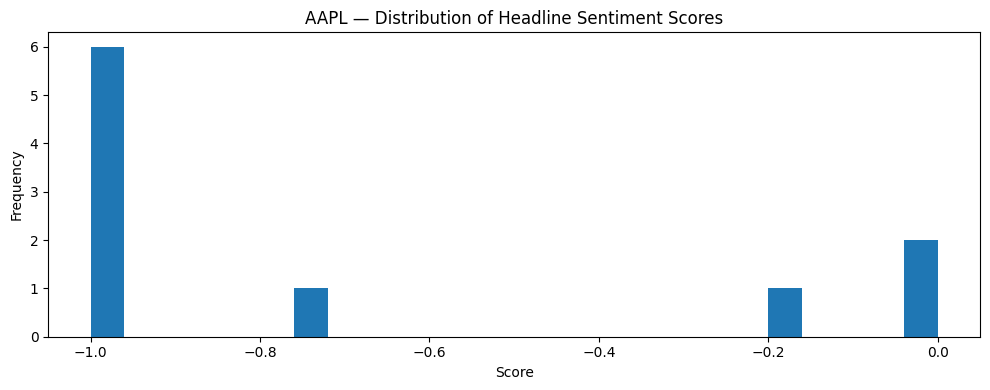

In [8]:
scores = news.loc[news["ticker"]==tkr, "score"].dropna()
plt.figure(figsize=(10,4))
plt.hist(scores, bins=25)
plt.title(f"{tkr} — Distribution of Headline Sentiment Scores")
plt.xlabel("Score"); plt.ylabel("Frequency"); plt.tight_layout(); plt.show()


# Show Examples (Most Positive / Most Negative)

In [9]:
def show_examples(df, tkr="AAPL", n=5):
    subset = df[df["ticker"]==tkr].dropna(subset=["score","title"])
    top = subset.sort_values("score", ascending=False).head(n)[["published_utc","publisher","score","title"]]
    bot = subset.sort_values("score", ascending=True).head(n)[["published_utc","publisher","score","title"]]
    print("Top positive:\n", top.to_string(index=False), "\n")
    print("Top negative:\n", bot.to_string(index=False))

show_examples(news, tkr=tkr, n=5)


Top positive:
             published_utc               publisher         score                                                                                    title
2025-12-18 21:34:59+00:00 The Wall Street Journal -1.676520e-08                                                  Heard on the Street Recap: Memory Boost
2025-12-18 15:31:20+00:00                     WWD -4.740597e-03                              Bernard Arnault Wins ‘Legend in Leadership’ Award From Yale
2025-12-18 17:08:00+00:00             Barrons.com -1.676621e-01 America’s 3 Most Important Companies Are About to Get New Leadership. Trust the Process.
2025-12-18 18:21:31+00:00           GuruFocus.com -7.437118e-01                                                          Apple Loosens iOS Grip in Japan
2025-12-18 12:00:39+00:00     Yahoo Finance Video -9.674379e-01                        Amazon, Apple, Google, etc.: Why the Mag 7 needs to 'recalibrate' 

Top negative:
             published_utc                 publishe

# Publisher Lens (who’s positive/negative?)

In [10]:
pub = (news.groupby("publisher")
            .agg(avg_sent=("score","mean"),
                 n=("score","count"))
            .reset_index())
pub = pub[pub["n"]>=5].sort_values("avg_sent", ascending=False)
pub.head(10)


,publisher,avg_sent,n
11,Motley Fool,-0.558908,7


# Rolling Sentiment Trend (7-day)

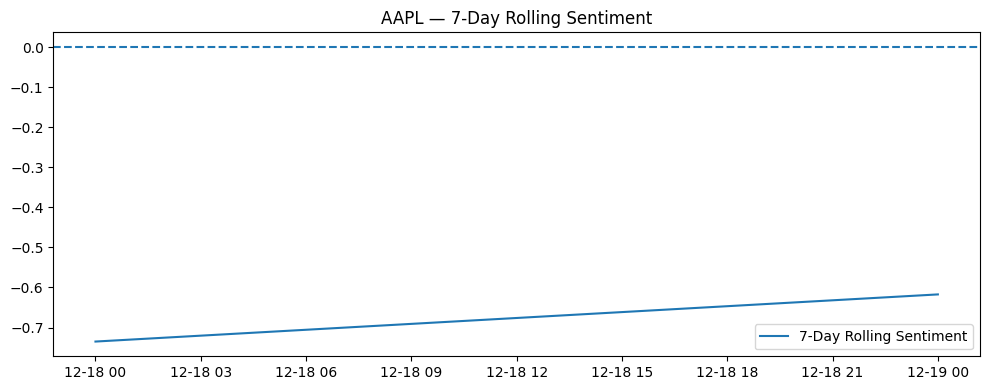

In [11]:
d2 = daily[daily["ticker"]==tkr].set_index("news_day").sort_index()
d2["sent_7d"] = d2["sent_mean"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(10,4))
plt.plot(d2.index, d2["sent_7d"], label="7-Day Rolling Sentiment")
plt.axhline(0, linestyle="--")
plt.title(f"{tkr} — 7-Day Rolling Sentiment")
plt.legend(); plt.tight_layout(); plt.show()
